# Auto-Labeler Training on Colab (A100)

1D U-Net for offline tissue segmentation — trains on 85 labeled studies.

**Setup:** Data is on Google Drive at `G:\My Drive\auto_labeler` (mounted as `/content/drive/MyDrive/auto_labeler`).

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!rm -rf /content/drive/MyDrive/auto_labeler/__pycache__
!cd /tmp && rm -rf PyTorch_3 && git clone https://github.com/RonInQu/PyTorch_3.git
!cp /tmp/PyTorch_3/auto_labeler/*.py /content/drive/MyDrive/auto_labeler/
print("Code synced from git")

Cloning into 'PyTorch_3'...
remote: Enumerating objects: 1008, done.
remote: Counting objects: 100% (445/445), done.
remote: Compressing objects: 100% (251/251), done.
remote: Total 1008 (delta 272), reused 326 (delta 167), pack-reused 563 (from 1)
Receiving objects: 100% (1008/1008), 498.24 KiB | 12.15 MiB/s, done.
Resolving deltas: 100% (626/626), done.
Code synced from git


In [3]:
# Set working directory to the auto_labeler folder on Google Drive
%cd /content/drive/MyDrive/auto_labeler

/content/drive/MyDrive/auto_labeler


In [4]:
# Verify directory contents
import os
print("Contents of working directory:")
for f in sorted(os.listdir(".")):
    print(f"  {f}")


Contents of working directory:
  UNet_1.ipynb
  __init__.py
  archive
  checkpoints
  config.py
  create_slides.py
  dataset.py
  evaluate.py
  interpret_layers.py
  model.py
  plot_predictions.py
  predict.py
  predict_labels
  results
  run_inference.py
  test_data
  train.py
  train_colab.ipynb
  training_data


In [5]:
# Verify GPU
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [6]:
# Install any missing dependencies
!pip install pandas pyarrow matplotlib -q

In [7]:
# Verify training data exists
import os
data_dir = "training_data"
files = [f for f in os.listdir(data_dir) if f.endswith('.parquet')]
print(f"Training parquets found: {len(files)}")
assert len(files) >= 85, f"Expected 85+ files, got {len(files)}. Check data_dir path."

Training parquets found: 85


In [8]:
# Verify model builds correctly
from model import UNet1D, count_parameters

model = UNet1D(in_channels=1, num_classes=3, base_filters=32, depth=5, kernel_size=7)
print(f"Parameters: {count_parameters(model):,}")

x = torch.randn(2, 1, 4096).cuda()
model = model.cuda()
y = model(x)
print(f"Input: {x.shape} -> Output: {y.shape}")
del model, x, y
torch.cuda.empty_cache()

Parameters: 27,263,875
Input: torch.Size([2, 1, 4096]) -> Output: torch.Size([2, 3, 4096])


## Train

With A100 + batch_size=64, expect ~20 minutes for 80 epochs, else with cpu, expect ~ 40 hours.

In [9]:
# Run training from parent directory so package imports work
%cd /content/drive/MyDrive

!python -m auto_labeler.train \
    --data_dir auto_labeler/training_data \
    --output_dir auto_labeler/checkpoints \

# Return to auto_labeler dir
%cd /content/drive/MyDrive/auto_labeler

/content/drive/MyDrive
Device: cuda
Loading data...
Train: 73 studies, Val: 12 studies
Multichannel: False (1 channel)
Train chunks: 11430, Val chunks: 859
Computing class weights...
Class weights: [1.0, 12.20568561553955, 19.549972534179688]
Model parameters: 27,263,875
Input channels: 1, Loss: ce, Dropout: 0

Training: 80 epochs, patience=15

Epoch   1/80 | Train Loss: 0.8534 | Val Loss: 0.6931 | Val F1: 0.6094 (0.919/0.359/0.550) | Acc: 0.8466 | 12.8s
  → Saved best model (F1=0.6094)
Epoch   2/80 | Train Loss: 0.7360 | Val Loss: 0.6349 | Val F1: 0.5909 (0.889/0.295/0.589) | Acc: 0.8039 | 12.0s
Epoch   3/80 | Train Loss: 0.6868 | Val Loss: 0.6095 | Val F1: 0.6145 (0.908/0.286/0.650) | Acc: 0.8309 | 12.0s
  → Saved best model (F1=0.6145)
Epoch   4/80 | Train Loss: 0.6516 | Val Loss: 0.5100 | Val F1: 0.7127 (0.958/0.566/0.614) | Acc: 0.9154 | 12.0s
  → Saved best model (F1=0.7127)
Epoch   5/80 | Train Loss: 0.6225 | Val Loss: 0.6039 | Val F1: 0.6616 (0.909/0.297/0.779) | Acc: 0.8351 | 

## Evaluate on Test Studies

In [10]:
# Evaluate on test studies (if they exist in test_data/)
%cd /content/drive/MyDrive/

!python -m auto_labeler.evaluate \
    --data_dir auto_labeler/test_data \
    --checkpoint auto_labeler/checkpoints/best_model.pt \
    --output_dir auto_labeler/results \
    --plot

%cd /content/drive/MyDrive/auto_labeler

/content/drive/MyDrive
Device: cuda
Multichannel: False
Evaluating 8 studies...
  33CFB812: F1=0.5030, Acc=0.8283
  Saved: auto_labeler/results/plots/33CFB812_overlay.png
  819421BC: F1=0.5408, Acc=0.7889
  Saved: auto_labeler/results/plots/819421BC_overlay.png
  847A1E3F: F1=0.6377, Acc=0.8840
  Saved: auto_labeler/results/plots/847A1E3F_overlay.png
  8ECEADA6: F1=0.7021, Acc=0.8592
  Saved: auto_labeler/results/plots/8ECEADA6_overlay.png
  CENT0008: F1=0.6912, Acc=0.8677
  Saved: auto_labeler/results/plots/CENT0008_overlay.png
  DD2DFAF4: F1=0.4504, Acc=0.7406
  Saved: auto_labeler/results/plots/DD2DFAF4_overlay.png
  F427536B: F1=0.3268, Acc=0.6788
  Saved: auto_labeler/results/plots/F427536B_overlay.png
  SUMM0127: F1=0.5053, Acc=0.7487
  Saved: auto_labeler/results/plots/SUMM0127_overlay.png

SUMMARY (8 studies)
  Accuracy:   0.7995 ± 0.0726
  F1 macro:   0.5447 ± 0.1279
  F1 blood : 0.8905 ± 0.0460
  F1 clot  : 0.1498 ± 0.1592
  F1 wall  : 0.5937 ± 0.2135
Results saved: auto_labe

Found 8 plots


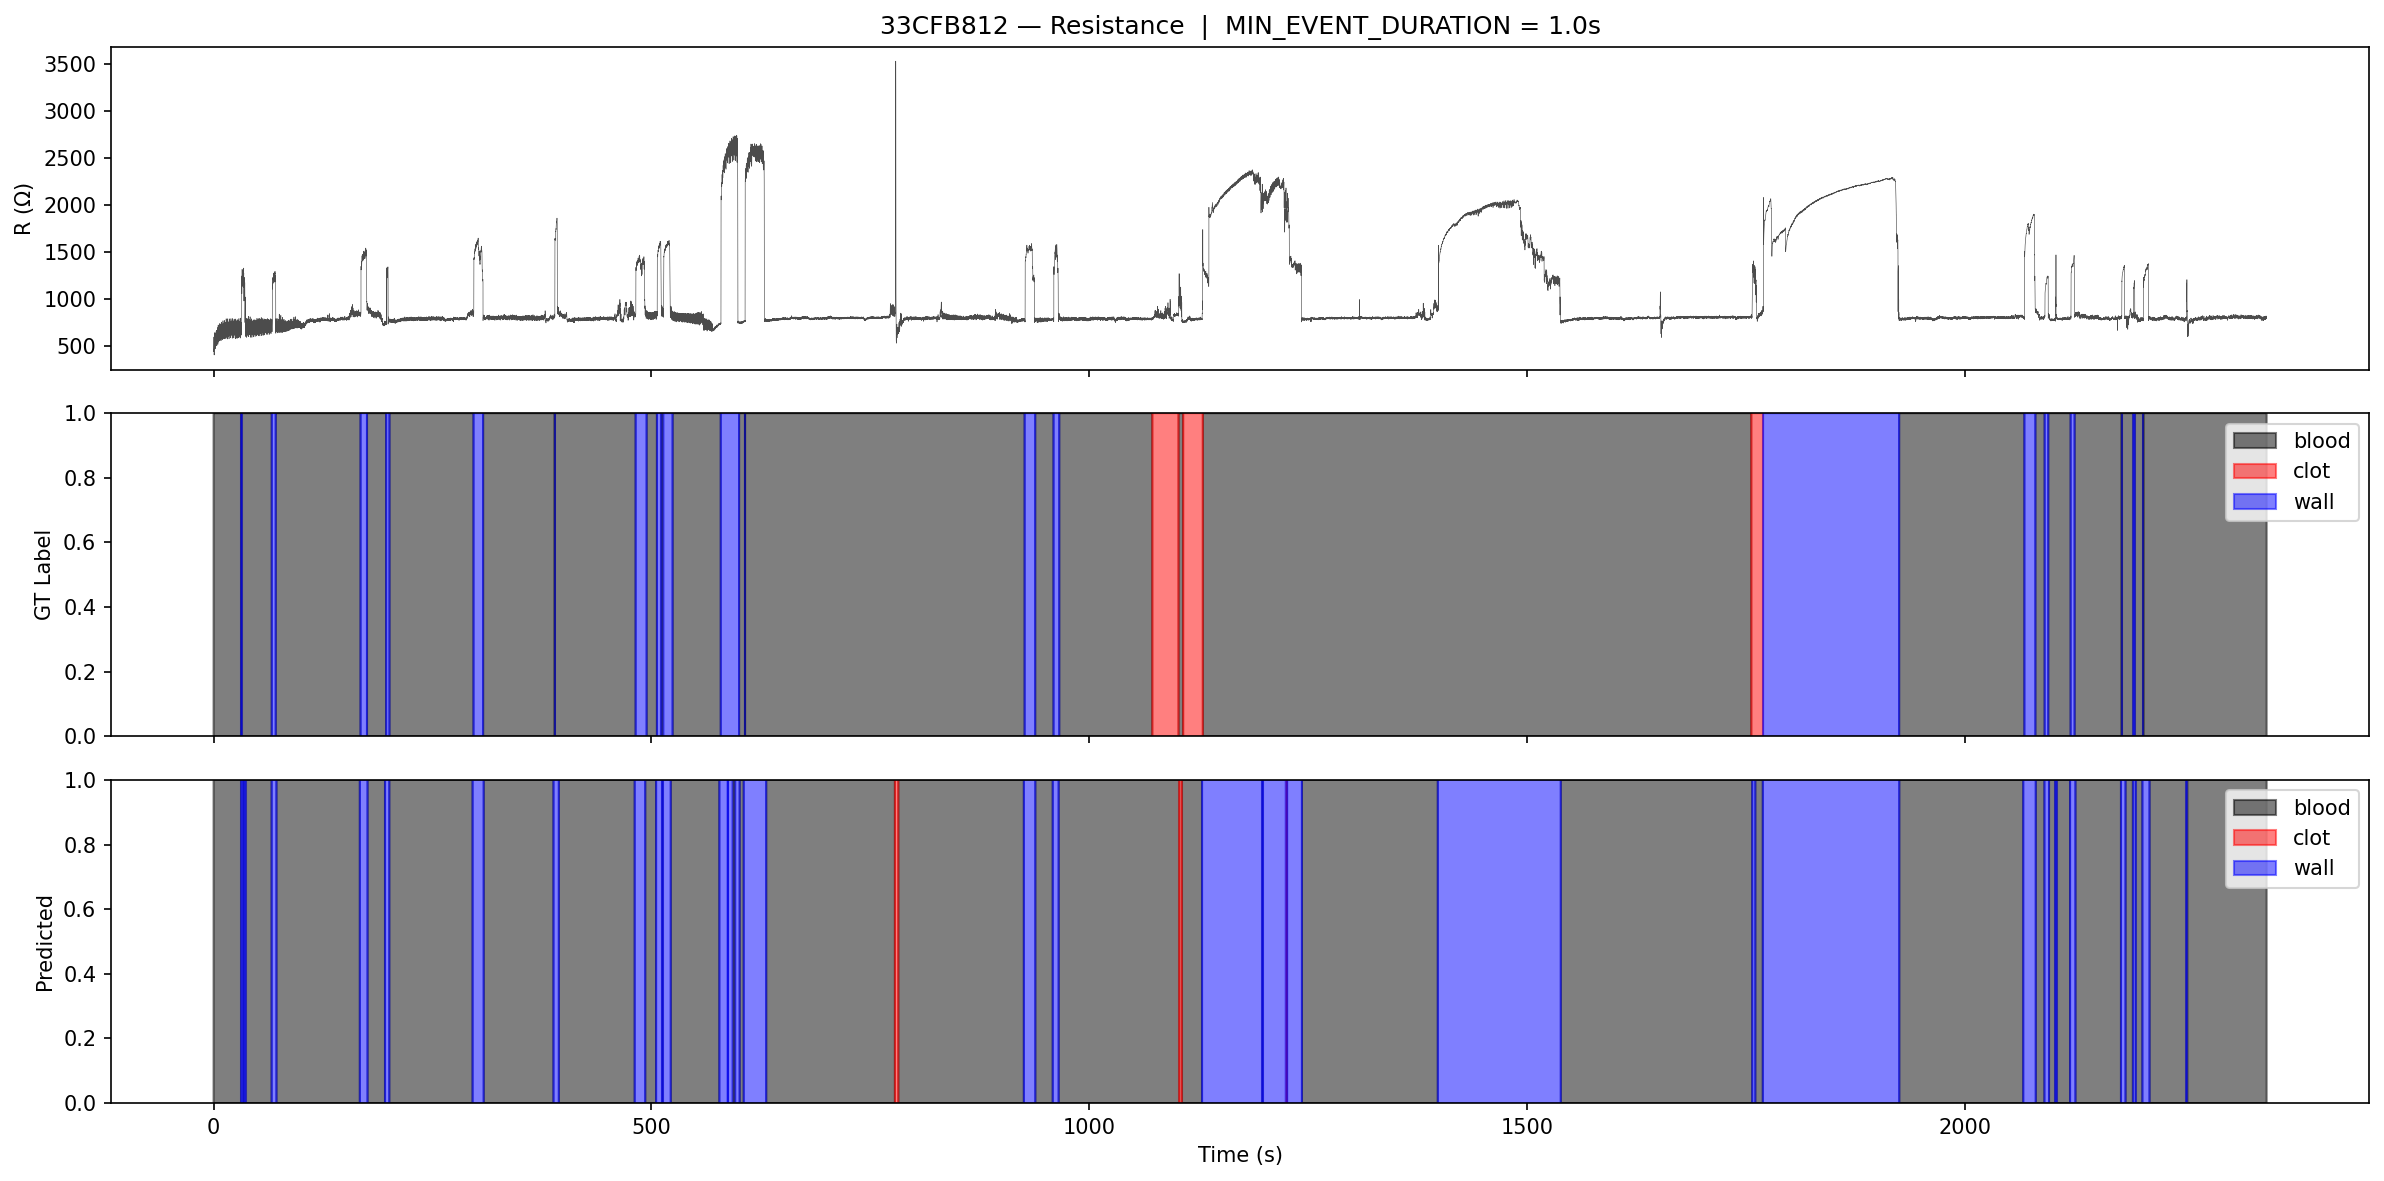

In [11]:
# View a sample overlay plot
from IPython.display import Image
import glob

plots = sorted(glob.glob("results/plots/*.png"))
if plots:
    print(f"Found {len(plots)} plots")
    display(Image(plots[0], width=1000))
else:
    print("No plots generated (test studies may not be in training_data/)")

## Download Trained Model

In [12]:
# Checkpoint is already on Google Drive (saved in-place during training)
print("Checkpoint location: /content/drive/MyDrive/auto_labeler/checkpoints/best_model.pt")
!ls -la checkpoints/best_model.pt

Checkpoint location: /content/drive/MyDrive/auto_labeler/checkpoints/best_model.pt
-rw------- 1 root root 327361763 Jun  8 22:20 checkpoints/best_model.pt


## Predict Labels on New Data

Place unlabeled parquet files in `auto_labeler/predict_labels/`. Each file should have columns `timeInMS` and `magRLoadAdjusted`. The model will add a `predicted_label` column (0=blood, 1=clot, 2=wall) and overwrite the file in-place.

In [13]:
%cd /content/drive/MyDrive/auto_labeler
import sys
sys.path.insert(0, "/content/drive/MyDrive")

import os
print(f"CWD: {os.getcwd()}")
print(f"Checkpoint exists: {os.path.exists('checkpoints/best_model.pt')}")
print(f"predict_labels/ exists: {os.path.exists('predict_labels')}")
if os.path.exists('predict_labels'):
    print(f"  Contents: {os.listdir('predict_labels')}")

import pandas as pd
import numpy as np
from pathlib import Path
from auto_labeler.predict import load_model, predict_file
from auto_labeler.dataset import build_multichannel
import torch

checkpoint = "checkpoints/best_model.pt"
predict_dir = Path("predict_labels")
predict_dir.mkdir(exist_ok=True)

# Find all parquet files to label
parquets = sorted(predict_dir.glob("*.parquet"))
print(f"\nFound {len(parquets)} files to label")

if not parquets:
    print("No .parquet files found. Place files in /content/drive/MyDrive/auto_labeler/predict_labels/")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, multichannel = load_model(checkpoint, device)
    print(f"Model loaded (multichannel={multichannel})")

    for pf in parquets:
        print(f"\n  Processing: {pf.name}")
        df = pd.read_parquet(pf)
        resistance = df["magRLoadAdjusted"].values.astype(np.float32)

        # Build features matching training
        if multichannel:
            features = build_multichannel(resistance)
        else:
            mean, std = resistance.mean(), resistance.std() + 1e-8
            features = ((resistance - mean) / std)[np.newaxis, :]

        # Run prediction
        pred_labels = predict_file(model, features, device)

        # Add predicted_label column
        df["predicted_label"] = pred_labels

        # Save back
        df.to_parquet(pf, index=False)

        # Summary
        unique, counts = np.unique(pred_labels, return_counts=True)
        label_names = {0: "blood", 1: "clot", 2: "wall"}
        dist = ", ".join(f"{label_names[u]}: {c/len(pred_labels)*100:.1f}%" for u, c in zip(unique, counts))
        print(f"    Samples: {len(pred_labels):,} | {dist}")

    print(f"\nDone! {len(parquets)} files labeled and saved.")

/content/drive/MyDrive/auto_labeler
CWD: /content/drive/MyDrive/auto_labeler
Checkpoint exists: True
predict_labels/ exists: True
  Contents: ['test.py', '33CFB812_labeled_segment.parquet', '819421BC_labeled_segment.parquet', '8ECEADA6_labeled_segment.parquet', 'CENT0008_labeled_segment.parquet', 'SUMM0127_labeled_segment.parquet', 'F427536B_labeled_segment.parquet', 'DD2DFAF4_labeled_segment.parquet', '847A1E3F_labeled_segment.parquet']

Found 8 files to label
Model loaded (multichannel=False)

  Processing: 33CFB812_labeled_segment.parquet
    Samples: 351,627 | blood: 74.0%, clot: 0.5%, wall: 25.5%

  Processing: 819421BC_labeled_segment.parquet
    Samples: 239,433 | blood: 69.0%, clot: 1.7%, wall: 29.3%

  Processing: 847A1E3F_labeled_segment.parquet
    Samples: 357,599 | blood: 80.6%, clot: 4.7%, wall: 14.6%

  Processing: 8ECEADA6_labeled_segment.parquet
    Samples: 284,908 | blood: 75.5%, clot: 6.9%, wall: 17.5%

  Processing: CENT0008_labeled_segment.parquet
    Samples: 261